Idea:

- Turn each meal into Darts' series with time as covariate
- Each restaurant corresponds with a dedicated forecasting model

In [1]:
%cd ../../

/Users/hoangle/Projects/untangling-people/ylva/fwo_models


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf
import polars as pl
from darts.models import NaiveMovingAverage, LinearRegressionModel, RandomForest, CatBoostModel, KalmanForecaster
from darts import TimeSeries
from darts.dataprocessing.transformers import Scaler, StaticCovariatesTransformer, MissingValuesFiller, InvertibleMapper
from darts.dataprocessing import Pipeline
from darts.metrics import mape
from tqdm import tqdm

In [3]:
plt.style.use('seaborn-v0_8')
plt.rcParams.update({'font.size': 8})


In [4]:
CUTOFF_DATE = "2025-01-01"

# Load dims and raw data

## dim `meals`

In [5]:
dim_meals = pl.read_parquet("data/processed/dim_meals.parquet")
dim_meals.head()

id,meal_codes,names,restaurants,meal_type,schoolyear,attributes,co2,src
i64,list[i64],list[str],list[i64],i64,str,list[str],f32,list[str]
0,[90000000],"[""Kikhernetaginea& syysomenajogurttia""]",[1],5,"""23-24""",[],0.41,"[""pos_Jan23-Oct24""]"
1,[90000001],"[""Rapea Meiramikana""]","[1, 4]",3,"""23-24""",[],1.26,"[""pos_Jan23-Oct24""]"
2,[7203],"[""Kasvismuhennos Caponata""]","[1, 2, 4]",4,"""23-24""",[],0.42,"[""pos_Jan23-Oct24"", ""menus_meals""]"
3,[9058],"[""TexMex-siemenpyöryköitä ja Arrabiattakastiketta"", ""TexMex-siemenpyöryköitä ja Arrabiattakastiket""]","[1, 2, 4]",4,"""24-25""","[""gluten_free"", ""vegan-kpl""]",0.56,"[""pos_Jan23-Oct24"", ""menus_meals"", … ""menus_week1-6""]"
4,[6877],"[""Kasvisjalapenonuggetteja, tomaattisalsaa"", ""Kasvis-jalapnuget ja tomatsals""]","[1, 2, 4]",4,"""24-25""",[],0.44,"[""pos_Jan23-Oct24"", ""menus_meals"", ""pos_Nov24-Mar25""]"


## dim `meal_types`

In [6]:
path = "data/processed/dim_meal_types.xlsx"
dim_meal_types = pl.read_excel(path)

dim_meal_types.head()

meal_type_id,meal_type,meal_type_en
i64,str,str
1,"""Kala""","""fish"""
2,"""Liha""","""meat"""
3,"""Kana""","""chicken"""
4,"""Vegaani""","""vegan"""
5,"""Kasvis""","""vegetarian"""


## dim `exams_uhelsinki`

In [7]:
path = "data/processed/dim_exams_uhelsinki.xlsx"
dim_exams_uhelsinki = pl.read_excel(path)

dim_exams_uhelsinki.head()

date,is_exam
date,bool
2023-01-01,false
2023-01-02,false
2023-01-03,false
2023-01-04,false
2023-01-05,false


## dim `holidays_uhelsinki`

In [8]:
path = "data/processed/dim_holidays_uhelsinki.xlsx"

dim_holidays_uhelsinki = pl.read_excel(path)
dim_holidays_uhelsinki.head()

date,is_holiday
date,bool
2023-01-01,true
2023-01-02,false
2023-01-03,false
2023-01-04,false
2023-01-05,false


## fact `pos`

In [9]:
path = "data/processed/pos.xlsx"
pos_raw = pl.read_excel(path)

pos_raw.head()

id,restaurant,meal_id,datetime,pcs,src
i64,i64,i64,datetime[ms],i64,str
0,1,55,2023-01-02 10:31:00,1,"""Sold lunches"""
1,1,8,2023-01-02 10:32:00,1,"""Sold lunches"""
2,1,55,2023-01-02 10:32:00,1,"""Sold lunches"""
3,1,8,2023-01-02 10:35:00,1,"""Sold lunches"""
4,1,55,2023-01-02 10:36:00,2,"""Sold lunches"""


In [10]:
pos = (
    pos_raw
    .with_columns(
        pl.col('datetime').dt.date().alias('date')
    )
    .group_by('restaurant', 'date', 'meal_id')
    .agg(pl.col('pcs').sum())


    # Add info for holiday and exam
    .join(dim_holidays_uhelsinki, on='date', how='left')
    .join(dim_exams_uhelsinki, on='date', how='left')
    .with_columns(
        pl.col('is_holiday').cast(pl.Int32),
        pl.col('is_exam').cast(pl.Int32)
    )
)


# Only keep entries of meals having data since CUTOFF_DATE
meals_concerned = (
    pos
    .filter(pl.col('date') >= pl.lit(CUTOFF_DATE, dtype=pl.Date))
    .select('meal_id', 'restaurant').unique()
)

pos = pos.join(meals_concerned, on=['meal_id', 'restaurant'], how='inner')


# Remove pos of leftover meals
pos = (
    pos
    .with_columns(
        pl.col('date').shift(1).over('restaurant', 'meal_id', order_by='date').alias('date_lag'),
        pl.col('pcs').shift(1).over('restaurant', 'meal_id', order_by='date').alias('pcs_lag'),
    )
    .filter(
        (pl.col('date_lag').is_null())
        | ((pl.col('date') - pl.col('date_lag')).dt.total_days() > 7)
    )
    .drop('date_lag', 'pcs_lag')
)


# Keep records whose POS value is greater than Q1 value
pos = (
    pos
    .with_columns(
        pl.col('pcs').quantile(.25).over('restaurant', 'meal_id', order_by='date').alias('pcs_q1'),
        pl.col('pcs').quantile(.75).over('restaurant', 'meal_id', order_by='date').alias('pcs_q3')
    )
    .filter(
        (1 == 1)
        & (pl.col('pcs') >= pl.col('pcs_q1'))
        & (pl.col('pcs') <= pl.col('pcs_q3'))
    )
    .drop('pcs_q1', 'pcs_q3')
)



# Add datetime attributes
pos = (
    pos
    .with_columns(
        pl.col('date').dt.weekday().alias('weekday'),
        pl.col('date').dt.day().alias('day'),
        pl.col('date').dt.week().alias('week'),
        pl.col('date').dt.month().alias('month'),
        pl.col('date').dt.year().alias('year'),
    )
    .with_columns(
        (pl.col('weekday') * 2 * np.pi / 7).sin().alias('weekday_sin'),
        (pl.col('weekday') * 2 * np.pi / 7).cos().alias('weekday_cos'),
        (pl.col('day') * 2 * np.pi / 31).sin().alias('day_sin'),
        (pl.col('day') * 2 * np.pi / 31).cos().alias('day_cos'),
        (pl.col('week') * 2 * np.pi / 53).sin().alias('week_sin'),
        (pl.col('week') * 2 * np.pi / 53).cos().alias('week_cos'),
        (pl.col('month') * 2 * np.pi / 12).sin().alias('month_sin'),
        (pl.col('month') * 2 * np.pi / 12).cos().alias('month_cos'),
    )
)


pos.head()

restaurant,date,meal_id,pcs,is_holiday,is_exam,weekday,day,week,month,year,weekday_sin,weekday_cos,day_sin,day_cos,week_sin,week_cos,month_sin,month_cos
i64,date,i64,i64,i32,i32,i8,i8,i8,i8,i32,f64,f64,f64,f64,f64,f64,f64,f64
1,2024-08-28,188,0,1,0,3,28,35,8,2024,0.433884,-0.900969,-0.571268,0.820763,-0.845596,-0.533823,-0.866025,-0.5
1,2023-03-02,260,188,0,0,4,2,9,3,2023,-0.433884,-0.900969,0.394356,0.918958,0.875735,0.482792,1.0,6.1232e-17
4,2023-02-07,119,1,0,0,2,7,6,2,2023,0.974928,-0.222521,0.988468,0.151428,0.652822,0.757511,0.866025,0.5
1,2024-03-28,92,192,1,0,4,28,13,3,2024,-0.433884,-0.900969,-0.571268,0.820763,0.999561,0.029633,1.0,6.1232e-17
3,2024-03-14,268,2,0,0,4,14,11,3,2024,-0.433884,-0.900969,0.299363,-0.954139,0.964636,0.263587,1.0,6.1232e-17


# Build Time series

In [11]:
col_tgt = 'pcs'

cols_cov = [
    'is_exam',
    # 'is_holiday',

    # 'weekday',
    # 'day',
    # 'week',
    # 'month',
    # 'year',

    # 'weekday_sin',
    # 'weekday_cos',
    # 'day_sin',
    # 'day_cos',
    # 'week_sin',
    # 'week_cos',
    # 'month_sin',
    # 'month_cos',
]

In [12]:
model_name = "rf"
THRES = 3

results = []
pipeline = Pipeline([
    # InvertibleMapper(np.log1p, np.expm1, verbose=False, n_jobs=-1, name="Log-Transform"),
    Scaler(verbose=False, n_jobs=-1, name="Scaling"),
])

# pairs = pos.select('restaurant', 'meal_id').unique()
for pair in tqdm(meals_concerned.iter_rows(named=True), total=len(meals_concerned)):
    df = (
        pos
        .filter(
            (1 == 1)
            & (pl.col('meal_id') == pair['meal_id'])
            & (pl.col('restaurant') == pair['restaurant'])
            & (pl.col(col_tgt) > 0)
        )
        .sort('date')
        .with_row_index('index')
        .to_pandas()
    )

    if len(df) < 3:
        continue

    series = TimeSeries.from_dataframe(
        df,
        time_col='index',
        value_cols=col_tgt,
        fillna_value=False,
        # static_covariates=pd.DataFrame(data={"meal_type": [entry['meal_type']]})
    )

    series_cov = TimeSeries.from_dataframe(
        df,
        time_col='index',
        value_cols=cols_cov,
        fillna_value=False,
        # static_covariates=pd.DataFrame(data={"meal_type": [entry['meal_type']]})
    )

    cutpoint = len(df[df['date'] <= CUTOFF_DATE])
    if cutpoint <= THRES or cutpoint == len(df) :
        continue


    series_train, series_test = series.split_before(cutpoint)


    series_train_transformed = pipeline.fit_transform(series_train)

    lags = min(5, len(series_train) - 1)
    match model_name:
        case "naive-moving":
            model = NaiveMovingAverage(lags)
            model.fit(series_train_transformed)
            preds = model.predict(len(series_test))
        case "linear":
            model = LinearRegressionModel(lags, lags_future_covariates=[0])
            model.fit(series_train_transformed, future_covariates=series_cov)
            preds = model.predict(len(series_test), future_covariates=series_cov)
        case "rf":
            model = RandomForest(lags, lags_future_covariates=[0])
            model.fit(series_train_transformed, future_covariates=series_cov)
            preds = model.predict(len(series_test), future_covariates=series_cov)
        case "kalman":
            model = KalmanForecaster(lags)
            model.fit(series_train_transformed, future_covariates=series_cov)
            preds = model.predict(len(series_test), future_covariates=series_cov)

    preds = pipeline.inverse_transform(preds)

    # Eval
    mape_val = mape(series_test, preds)

    # fig = plt.figure(figsize=(8, 6))
    # ax = fig.add_subplot(111)

    # series_train.plot(ax=ax, label='train')
    # series_test.plot(ax=ax, label='test-gt')
    # preds.plot(ax=ax, label='test-pred')

    # fig.suptitle(f"meal_id = {meal_id['meal_id']} | MAPE = {mape_val.item():.4f}", fontsize=20, fontweight='bold')
    

    results.append({**pair, 'mape': mape_val.item()})

  0%|          | 0/340 [00:00<?, ?it/s]

100%|██████████| 340/340 [00:19<00:00, 17.28it/s]


In [16]:
(
    pl
    .from_dicts(results)
    # .sort('mape', descending=True)
    .group_by('restaurant')
    .agg(pl.col('mape').mean())
)
    # .head()

restaurant,mape
i64,f64
2,25.231182
3,54.490858
4,21.818017
1,22.123504


Text(0.5, 0.98, 'meal_id = 321 | MAPE = 137.7500')

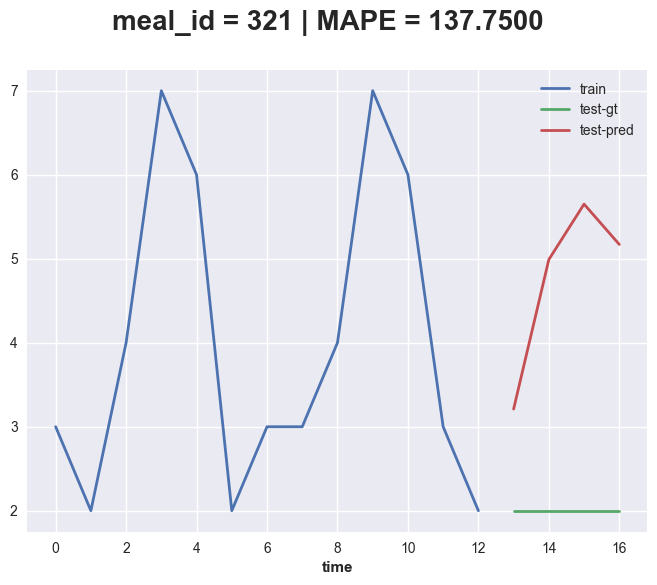

In [15]:
meal_id = 321
restaurant = 3

df = (
    pos
    .filter(
        (1 == 1)
        & (pl.col('meal_id') == meal_id)
        & (pl.col('restaurant') == restaurant)
        & (pl.col(col_tgt) > 0)
    )
    .sort('date')
    .to_pandas()
)

series = TimeSeries.from_dataframe(
    df,
    value_cols=col_tgt,
    fillna_value=False,
    # static_covariates=pd.DataFrame(data={"meal_type": [entry['meal_type']]})
)

series_cov = TimeSeries.from_dataframe(
    df,
    value_cols=cols_cov,
    fillna_value=False,
    # static_covariates=pd.DataFrame(data={"meal_type": [entry['meal_type']]})
)

cutpoint = len(df[df['date'] <= CUTOFF_DATE])


series_train, series_test = series.split_before(cutpoint)

pipeline = Pipeline([
    # InvertibleMapper(np.log1p, np.expm1, verbose=False, n_jobs=-1, name="Log-Transform"),
    Scaler(verbose=False, n_jobs=-1, name="Scaling"),
])
series_train_transformed = pipeline.fit_transform(series_train)

lags = min(5, len(series_train))
match model_name:
    case "naive-moving":
        model = NaiveMovingAverage(lags)
        model.fit(series_train_transformed)
        preds = model.predict(len(series_test))
    case "linear":
        model = LinearRegressionModel(lags, lags_future_covariates=[0])
        model.fit(series_train_transformed, future_covariates=series_cov)
        preds = model.predict(len(series_test), future_covariates=series_cov)
    case "rf":
        model = RandomForest(lags, lags_future_covariates=[0])
        model.fit(series_train_transformed, future_covariates=series_cov)
        preds = model.predict(len(series_test), future_covariates=series_cov)
    case "kalman":
        model = KalmanForecaster(lags)
        model.fit(series_train_transformed, future_covariates=series_cov)
        preds = model.predict(len(series_test), future_covariates=series_cov)

preds = pipeline.inverse_transform(preds)

# Eval
mape_val = mape(series_test, preds)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)

series_train.plot(ax=ax, label='train')
series_test.plot(ax=ax, label='test-gt')
preds.plot(ax=ax, label='test-pred')

fig.suptitle(f"meal_id = {meal_id} | MAPE = {mape_val.item():.4f}", fontsize=20, fontweight='bold')

In [34]:
(
    pos_raw
    .with_columns(
        pl.col('datetime').dt.date().alias('date')
    )
    .group_by('restaurant', 'date', 'meal_id')
    .agg(pl.col('pcs').sum())

    .with_columns(
        pl.col('pcs').quantile(.25).over('restaurant', 'meal_id', order_by='date').alias('pcs_q1')
    )

    .filter(
        (1 == 1)
        & (pl.col('meal_id') == meal_id)
        & (pl.col('restaurant') == restaurant)
        & (pl.col(col_tgt) > 0)
    )
    .sort('date', descending=True)
)

restaurant,date,meal_id,pcs,pcs_q1
i64,date,i64,i64,f64
1,2025-02-21,68,4,56.0
1,2025-01-27,68,68,56.0
1,2025-01-24,68,704,56.0
1,2024-12-16,68,1424,56.0
1,2024-10-18,68,52,56.0
…,…,…,…,…
1,2023-01-30,68,596,56.0
1,2023-01-18,68,22,56.0
1,2023-01-17,68,334,56.0
